In [64]:
import pandas as pd

df = pd.read_csv('../data/two_family/two_bedroom_home_values_zhvi.csv')
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,83344.619196,83497.156791,83684.847454,84091.160679,84557.592462,...,277241.936397,277526.843786,277198.318728,276742.253826,276169.920203,275633.122039,275112.204608,274665.813407,274477.206797,274460.149670
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.543280,501943.159082,502520.987387,503787.986518,505959.517755
2,753899,2,"Los Angeles, CA",msa,CA,169268.869371,169770.742761,170557.108176,172122.066322,173918.512499,...,739340.366867,737367.317096,732430.376873,727847.217695,723154.901146,719715.670089,717796.297400,717200.432449,717758.646596,719204.031024
3,394463,3,"Chicago, IL",msa,IL,101240.341888,101307.680756,101494.824515,101957.624150,102486.461458,...,252355.909350,253601.969084,254472.719490,255259.830574,255858.780978,256472.099230,257137.517327,257805.365792,258636.005319,259640.316581
4,394514,4,"Dallas, TX",msa,TX,69947.134256,69950.433460,69921.040192,69949.877922,70042.336016,...,231877.347334,231554.401161,230705.281883,229449.430718,227668.139913,225851.865008,224088.182881,222762.971545,221753.254434,220990.167480


In [65]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist()[:10], "...")  # Show first 10 columns
print(f"\nTotal columns: {len(df.columns)}")


Dataset Shape: (851, 315)

Column Names:
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31'] ...

Total columns: 315


In [66]:
# Check for New York in the dataset
print("Unique Region Names (first 20):")
print(df['RegionName'].unique()[:20])
print("\nChecking for New York:")
ny_regions = df[df['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_regions)} regions with 'New York' in name:")
print(ny_regions[['RegionName', 'StateName']].to_string())


Unique Region Names (first 20):
['United States' 'New York, NY' 'Los Angeles, CA' 'Chicago, IL'
 'Dallas, TX' 'Houston, TX' 'Washington, DC' 'Philadelphia, PA'
 'Miami, FL' 'Atlanta, GA' 'Boston, MA' 'Phoenix, AZ' 'San Francisco, CA'
 'Riverside, CA' 'Detroit, MI' 'Seattle, WA' 'Minneapolis, MN'
 'San Diego, CA' 'Tampa, FL' 'Denver, CO']

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [67]:
import matplotlib.pyplot as plt

# Filter for New York and save to house_prices_df
house_prices_df = df[df["RegionName"] == "New York, NY"].copy()
print(f"Selected region: {house_prices_df[['RegionName', 'StateName']].values}")

# Drop non-date columns
price_data = house_prices_df.loc[:, "2015-01-31":]

# Convert to long format
price_long = price_data.melt(var_name="Date", value_name="MedianPrice")

# Convert Date column to datetime
price_long["Date"] = pd.to_datetime(price_long["Date"])
price_long["Date"] = price_long["Date"].dt.to_period("M").dt.to_timestamp()

# Sort by date
price_long = price_long.sort_values("Date")

# Basic stats on the price data
print(f"\nPrice data statistics:")
print(price_long['MedianPrice'].describe())
print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
print(f"Total data points: {len(price_long)}")
print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")

Selected region: [['New York, NY' 'NY']]

Price data statistics:
count       130.000000
mean     374432.926711
std       73976.316198
min      273827.089475
25%      311339.503939
50%      354910.740756
75%      436564.746070
max      505959.517755
Name: MedianPrice, dtype: float64

Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00
Total data points: 130
Missing values: 0


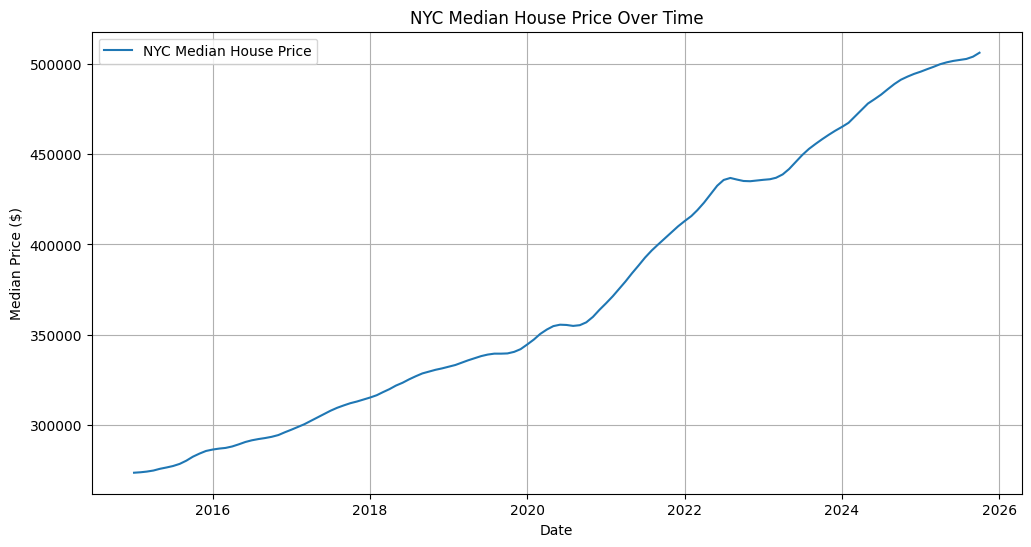

In [68]:
plt.figure(figsize=(12, 6))
plt.plot(
    price_long["Date"], price_long["MedianPrice"], label="NYC Median House Price"
)
plt.title("NYC Median House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [69]:
house_prices_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.54328,501943.159082,502520.987387,503787.986518,505959.517755


In [70]:
house_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 1 to 1
Columns: 315 entries, RegionID to 2025-10-31
dtypes: float64(310), int64(2), object(3)
memory usage: 2.5+ KB


In [71]:
# Check for duplicates
print("Duplicate rows:", house_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", house_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [72]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())
print("\nMissing values by column:")
print(house_prices_df.isna().sum()[house_prices_df.isna().sum() > 0])

Total missing values: 0

Missing values by column:
Series([], dtype: int64)


In [73]:
# Fill missing value using forward fill
house_prices_df = house_prices_df.fillna(method='ffill', axis=1)

C:\Users\Mohammed Al-Muqsit\AppData\Local\Temp\ipykernel_29280\2686464598.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  house_prices_df = house_prices_df.fillna(method='ffill', axis=1)


In [74]:
# Check for missing values
print("Total missing values:", house_prices_df.isna().sum().sum())


Total missing values: 0


In [75]:
# Check what columns are in price_long
print("Columns:", price_long.columns.tolist())
print("\nFirst few rows:")
price_long.head()

Columns: ['Date', 'MedianPrice']

First few rows:


,Date,MedianPrice
0,2015-01-01,273827.089475
1,2015-02-01,274085.123904
2,2015-03-01,274448.972557
3,2015-04-01,275038.062753
4,2015-05-01,275987.764520


In [76]:
price_long.tail()

,Date,MedianPrice
125,2025-06-01,501426.543280
126,2025-07-01,501943.159082
127,2025-08-01,502520.987387
128,2025-09-01,503787.986518
129,2025-10-01,505959.517755


In [95]:
price_long.to_csv("../data/cleaned/house_price_long.csv", index=False)


In [77]:
# Prepare for Prophet (needs 'ds' and 'y' columns)
price_long_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

In [78]:
# ============================================
# RENTAL PRICES PREPROCESSING
# ============================================

# Read rental prices data
df_rental = pd.read_csv('../data/two_family/multifamily_rental_values_zori.csv')
df_rental.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1158.783988,1163.832511,1171.228028,1175.383296,1179.722988,...,1759.350958,1762.586059,1764.857840,1766.494654,1767.438485,1769.352650,1771.503856,1774.625304,1777.314551,1779.303397
1,394913,1,"New York, NY",msa,NY,2264.111314,2278.386759,2291.166855,2302.839542,2309.751952,...,3245.116452,3258.020542,3269.225487,3278.078413,3285.458244,3298.403296,3318.815111,3340.302367,3357.934444,3372.411185
2,753899,2,"Los Angeles, CA",msa,CA,1671.176815,1680.585170,1693.221301,1708.879031,1722.529108,...,2651.097018,2656.867508,2659.684129,2660.694913,2660.979740,2663.835613,2665.229675,2669.891583,2672.608704,2675.925646
3,394463,3,"Chicago, IL",msa,IL,1312.935431,1313.914270,1319.733261,1322.067956,1326.647735,...,1889.175377,1898.419009,1907.877827,1917.834781,1927.050832,1936.667240,1946.329096,1955.600635,1964.607449,1971.554976
4,394514,4,"Dallas, TX",msa,TX,1040.141326,1036.535751,1039.603121,1052.215637,1058.206610,...,1522.378780,1523.219947,1522.109029,1522.868214,1520.149379,1518.771051,1516.142182,1515.500922,1515.062818,1512.591988


In [79]:
# Basic information
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")

Dataset Shape: (584, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


In [80]:
# Data types and info
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Columns: 135 entries, RegionID to 2025-10-31
dtypes: float64(130), int64(2), object(3)
memory usage: 616.1+ KB


In [81]:
# Check for New York
print("Checking for New York:")
ny_rental = df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)]
print(f"Found {len(ny_rental)} regions with 'New York' in name:")
print(ny_rental[['RegionName', 'StateName']].to_string())

Checking for New York:
Found 1 regions with 'New York' in name:
     RegionName StateName
1  New York, NY        NY


In [82]:
# Filter for New York and save to rental_prices_df
rental_prices_df = df_rental[df_rental['RegionName'] == 'New York, NY'].copy()
# Or try: df_rental[df_rental['RegionName'].str.contains('New York', case=False, na=False)].copy()
print(f"Selected region: {rental_prices_df[['RegionName', 'StateName']].values}")
print(f"Shape: {rental_prices_df.shape}")

Selected region: [['New York, NY' 'NY']]
Shape: (1, 135)


In [83]:
# Check for duplicates
print("Duplicate rows:", rental_prices_df.duplicated().sum())
print("Duplicate RegionIDs:", rental_prices_df.duplicated(subset=['RegionID']).sum())

Duplicate rows: 0
Duplicate RegionIDs: 0


In [84]:
# Check for missing values
print("Total missing values:", rental_prices_df.isna().sum().sum())


Total missing values: 7


In [85]:
# Drop non-date columns
rental_price_data = rental_prices_df.loc[:, "2015-01-31":]  # Adjust start date as needed

# Convert to long format
rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")

# Convert Date column to datetime
rental_long["Date"] = pd.to_datetime(rental_long["Date"])

# Sort by date
rental_long = rental_long.sort_values("Date")

# Set Date as index
rental_long = rental_long.set_index("Date")

# Basic stats on the rental data
print(f"\nRental data statistics:")
print(rental_long['RentalPrice'].describe())
print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
print(f"Total data points: {len(rental_long)}")
print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")


Rental data statistics:
count     123.000000
mean     2679.910984
std       348.842085
min      2264.111314
25%      2397.551613
50%      2512.327970
75%      3026.686119
max      3372.411185
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 7


In [86]:
# COVID Gap
rental_long[rental_long["RentalPrice"].isna()]

,RentalPrice
Date,
2020-03-31,NaN
2020-04-30,NaN
2020-05-31,NaN
2020-06-30,NaN
2020-07-31,NaN
2020-08-31,NaN
2020-09-30,NaN


In [87]:
# Apply interpolation to fill missing values
rental_long = rental_long.sort_index()

rental_long["RentalPrice"] = rental_long["RentalPrice"].interpolate(method="time")

In [91]:
print('Missing Values:', rental_long["RentalPrice"].isna().sum())

Missing Values: 0


In [97]:
rental_long.index = rental_long.index.to_period("M").to_timestamp()
rental_long.to_csv("../data/cleaned/rental_long.csv", index=True)

rental_long


,RentalPrice
Date,
2015-01-01,2264.111314
2015-02-01,2278.386759
2015-03-01,2291.166855
2015-04-01,2302.839542
2015-05-01,2309.751952
...,...
2025-06-01,3298.403296
2025-07-01,3318.815111
2025-08-01,3340.302367


In [92]:
# Verify ready for time series
print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
print("Total points:", len(rental_long))
print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
print("No missing:", rental_long['RentalPrice'].isna().sum() == 0)
print("No duplicates:", rental_long.index.duplicated().sum() == 0)
print("Is sorted:", rental_long.index.is_monotonic_increasing)

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total points: 130
Date is datetime: True
No missing: True
No duplicates: True
Is sorted: True


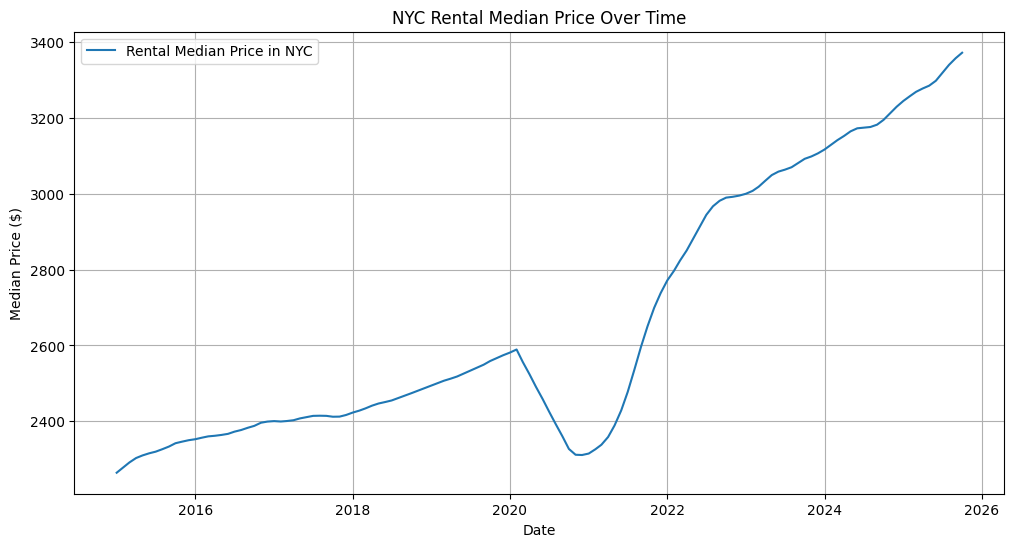

In [102]:
plt.figure(figsize=(12, 6))
plt.plot(
    rental_long.index, rental_long["RentalPrice"], label="Rental Median Price in NYC"
)
plt.title("NYC Rental Median Price Over Time")
plt.xlabel("Date")
plt.ylabel("Median Price ($)")
plt.legend()
plt.grid(True)
plt.show()


In [118]:
# ============================================
# MORTGAGE RATES PREPROCESSING (Monthly Mean)
# ============================================

from fredapi import Fred
import os
from dotenv import load_dotenv
import pandas as pd

# Load environment variables from .env file
load_dotenv()

# Get FRED API key from environment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Pull 30-Year Fixed Rate Mortgage, weekly data
mortgage = fred.get_series(
    "MORTGAGE30US", start_date="2015-01-01", end_date="2025-12-01"
)

# Convert to DataFrame
mortgage_df = mortgage.to_frame(name="mortgage_rate")
mortgage_df.index.name = "Date"

# Reset index to have Date as a column
mortgage_df = mortgage_df.reset_index()

# Filter for dates from 2015-01-01 onward
mortgage_df = mortgage_df[mortgage_df["Date"] >= "2015-01-01"]

# Convert Date to datetime
mortgage_df["Date"] = pd.to_datetime(mortgage_df["Date"])

# Set Date as index for resampling
mortgage_df = mortgage_df.set_index("Date")

# Resample to monthly frequency, taking the mean of all weeks in the month
mortgage_monthly = mortgage_df.resample("MS").mean()  # 'MS' = Month Start

# Reset index to have Date as a column
mortgage_monthly = mortgage_monthly.reset_index()


# Optional: preview
print(mortgage_monthly.head())
print(
    f"\nDate range: {mortgage_monthly['Date'].min()} to {mortgage_monthly['Date'].max()}"
)
print(f"Total data points: {len(mortgage_monthly)}")


        Date  mortgage_rate
0 2015-01-01          3.670
1 2015-02-01          3.710
2 2015-03-01          3.770
3 2015-04-01          3.672
4 2015-05-01          3.840

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Total data points: 132


In [119]:
# Save to CSV
mortgage_monthly.to_csv(
    "../data/cleaned/mortgage_monthly.csv",  
    index=True,
    float_format='%.2f')

mortgage_monthly = mortgage_monthly.set_index("Date")
mortgage_monthly.index = pd.to_datetime(mortgage_monthly.index)

mortgage_monthly

,mortgage_rate
Date,
2015-01-01,3.6700
2015-02-01,3.7100
2015-03-01,3.7700
2015-04-01,3.6720
2015-05-01,3.8400
...,...
2025-08-01,6.5875
2025-09-01,6.3525
2025-10-01,6.2540


In [121]:
# ============================================
# MERGE ALL DATA
# ============================================

# Reset indices to merge on Date
price_long_reset = price_long.reset_index()
rental_long_reset = rental_long.reset_index()
mortgage_reset = mortgage_monthly.reset_index()

# Convert all dates to end of month for alignment
price_long_reset['Date'] = pd.to_datetime(price_long_reset['Date'])
rental_long_reset['Date'] = pd.to_datetime(rental_long_reset['Date'])
mortgage_reset['Date'] = pd.to_datetime(mortgage_reset['Date'])

# Merge house prices and rental prices first (both monthly)
merged_df = pd.merge(price_long_reset, rental_long_reset, on='Date', how='inner')

# Merge with mortgage rates
merged_df = pd.merge(merged_df, mortgage_reset, on='Date', how='inner')

# Sort by date
merged_df = merged_df.sort_values('Date')

# Filter to common date range (2015 onwards where all data exists)
merged_df = merged_df[merged_df['Date'] >= '2015-01-01']

# Set Date as index
merged_df = merged_df.set_index('Date')

print("Merged dataset shape:", merged_df.shape)
print("\nFirst few rows:")
print(merged_df.head())
print("\nLast few rows:")
print(merged_df.tail())
print("\nMissing values:")
print(merged_df.isna().sum())


Merged dataset shape: (130, 4)

First few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2015-01-01      0  273827.089475  2264.111314          3.670
2015-02-01      1  274085.123904  2278.386759          3.710
2015-03-01      2  274448.972557  2291.166855          3.770
2015-04-01      3  275038.062753  2302.839542          3.672
2015-05-01      4  275987.764520  2309.751952          3.840

Last few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2025-06-01    125  501426.543280  3298.403296         6.8175
2025-07-01    126  501943.159082  3318.815111         6.7200
2025-08-01    127  502520.987387  3340.302367         6.5875
2025-09-01    128  503787.986518  3357.934444         6.3525
2025-10-01    129  505959.517755  3372.411185         6.2540

Missing values:
index            0
MedianPrice      0
RentalPrice      0
mortgage

In [122]:
merged_df.to_csv("../data/cleaned/merged_housing_data.csv", index=True)

In [123]:
# ============================================
# TIME SERIES FORECASTING WITH PROPHET
# ============================================

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')


c:\Users\Mohammed Al-Muqsit\Desktop\Repo\csc460Final\csc46000-team-project-4727\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [124]:
# Prepare house prices for Prophet (needs 'ds' and 'y' columns)
house_prices_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})

# Create and fit Prophet model for house prices
model_house = Prophet()
model_house.fit(house_prices_prophet)

# Create future dataframe (5 years = 60 months, 10 years = 120 months)
future_house = model_house.make_future_dataframe(periods=120, freq='M')  # 10 years forecast

# Make forecast
forecast_house = model_house.predict(future_house)

print("House Prices Forecast:")
print(f"Forecast period: {forecast_house['ds'].min()} to {forecast_house['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_house[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:21:49 - cmdstanpy - INFO - Chain [1] start processing
20:21:49 - cmdstanpy - INFO - Chain [1] done processing


House Prices Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-09-30 00:00:00

Last 5 forecasted values:
            ds           yhat     yhat_lower     yhat_upper
245 2035-05-31  776464.285609  614340.485778  946063.772948
246 2035-06-30  779579.403573  616219.900049  953025.361081
247 2035-07-31  781600.657001  615957.143760  956742.914164
248 2035-08-31  783010.275579  617220.345341  959995.197904
249 2035-09-30  784195.610505  614849.556958  965532.821704


In [125]:
# Prepare rental prices for Prophet
rental_prices_prophet = rental_long.reset_index().rename(columns={'Date': 'ds', 'RentalPrice': 'y'})

# Create and fit Prophet model for rental prices
model_rental = Prophet()
model_rental.fit(rental_prices_prophet)

# Create future dataframe (10 years forecast)
future_rental = model_rental.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_rental = model_rental.predict(future_rental)

print("Rental Prices Forecast:")
print(f"Forecast period: {forecast_rental['ds'].min()} to {forecast_rental['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_rental[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:41:16 - cmdstanpy - INFO - Chain [1] start processing
20:41:16 - cmdstanpy - INFO - Chain [1] done processing


Rental Prices Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-09-30 00:00:00

Last 5 forecasted values:
            ds         yhat  yhat_lower   yhat_upper
245 2035-05-31  4609.484507  683.584891  8493.035456
246 2035-06-30  4617.739169  621.848599  8552.157699
247 2035-07-31  4629.103191  572.752430  8616.996114
248 2035-08-31  4642.773430  515.669449  8676.051666
249 2035-09-30  4659.610008  445.870728  8741.727859


In [126]:
# Forecast mortgage rates
mortgage_prophet = mortgage_monthly.reset_index().rename(
    columns={"Date": "ds", "mortgage_rate": "y"}
)

# Create and fit Prophet model for mortgage rates
model_mortgage = Prophet()
model_mortgage.fit(mortgage_prophet)

# Create future dataframe (10 years forecast)
future_mortgage = model_mortgage.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_mortgage = model_mortgage.predict(future_mortgage)

print("Mortgage Rates Forecast:")
print(f"Forecast period: {forecast_mortgage['ds'].min()} to {forecast_mortgage['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_mortgage[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


20:42:36 - cmdstanpy - INFO - Chain [1] start processing
20:42:36 - cmdstanpy - INFO - Chain [1] done processing


Mortgage Rates Forecast:
Forecast period: 2015-01-01 00:00:00 to 2035-11-30 00:00:00

Last 5 forecasted values:
            ds       yhat  yhat_lower  yhat_upper
247 2035-07-31  14.301436   12.677783   16.054035
248 2035-08-31  14.419601   12.685364   16.288226
249 2035-09-30  14.669997   12.947861   16.433282
250 2035-10-31  14.713576   12.958409   16.477868
251 2035-11-30  14.608089   12.919183   16.357665


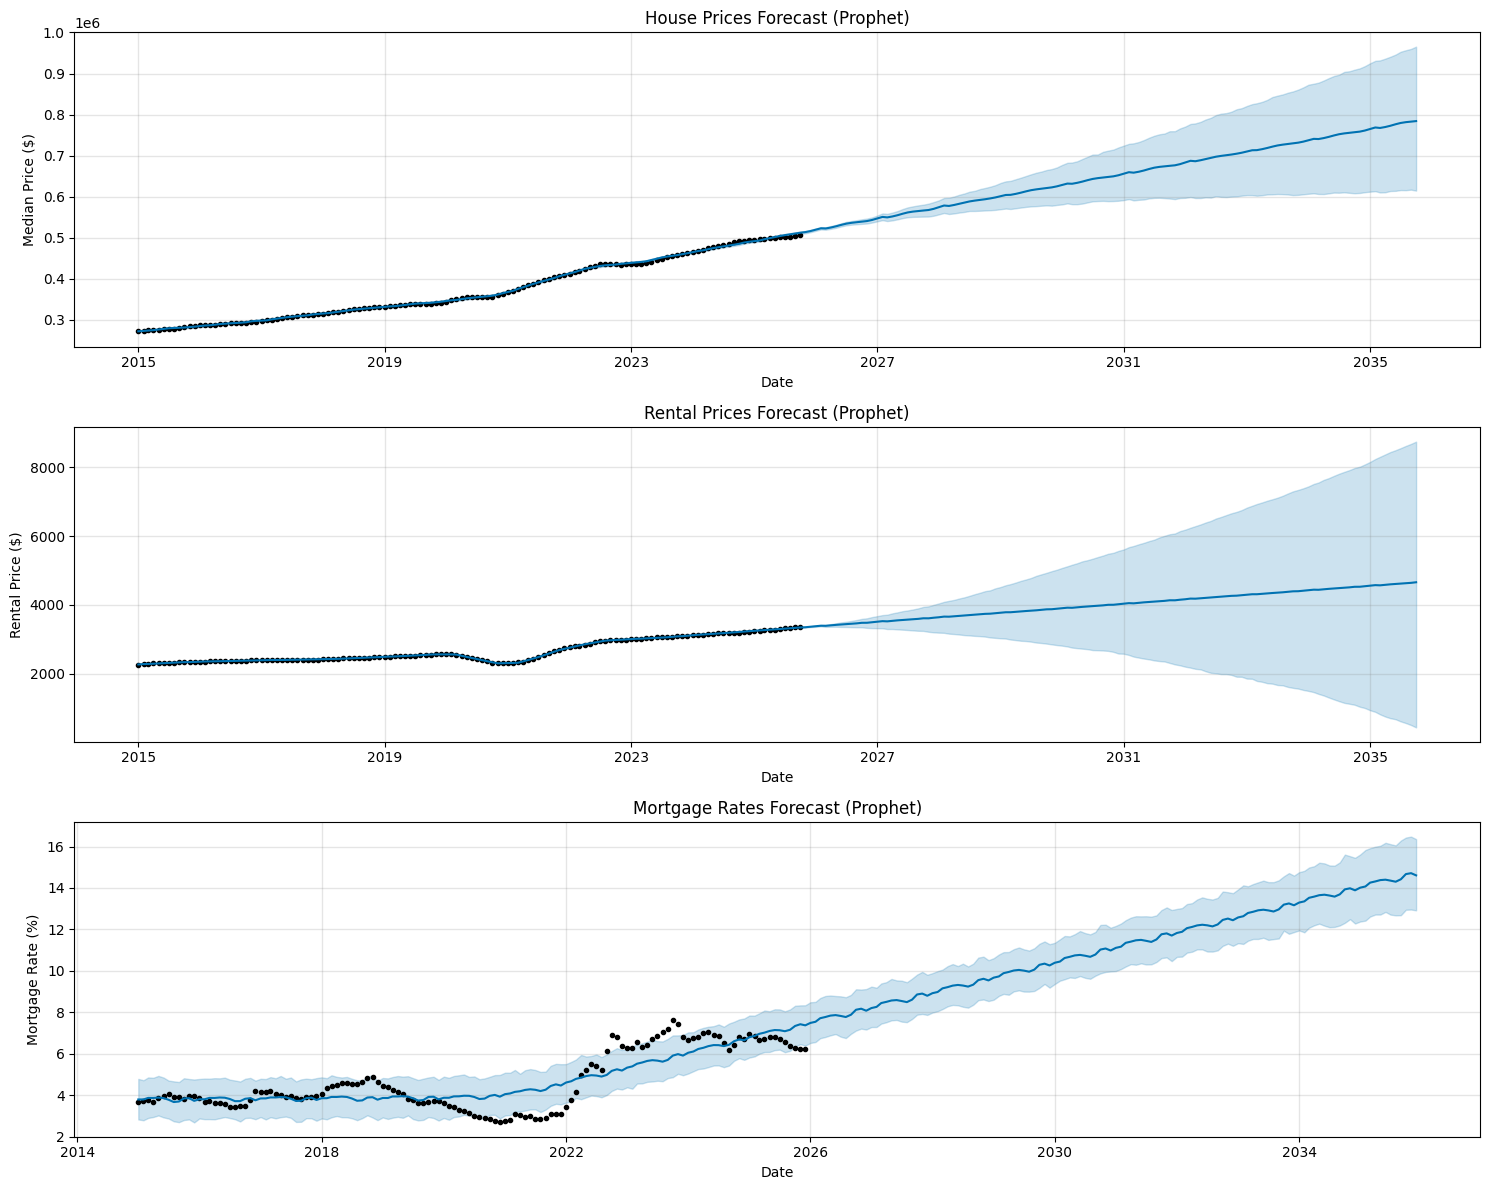

In [127]:
# Visualize forecasts
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# House prices forecast
model_house.plot(forecast_house, ax=axes[0])
axes[0].set_title('House Prices Forecast (Prophet)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Median Price ($)')

# Rental prices forecast
model_rental.plot(forecast_rental, ax=axes[1])
axes[1].set_title('Rental Prices Forecast (Prophet)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Rental Price ($)')

# Mortgage rates forecast
model_mortgage.plot(forecast_mortgage, ax=axes[2])
axes[2].set_title('Mortgage Rates Forecast (Prophet)')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mortgage Rate (%)')

plt.tight_layout()
plt.show()


In [128]:
# Extract forecasted values for future dates (beyond historical data)
# Get the last date from historical data
last_historical_date_house = house_prices_prophet['ds'].max()
last_historical_date_rental = rental_prices_prophet['ds'].max()
last_historical_date_mortgage = mortgage_prophet['ds'].max()

# Filter forecasts to only future dates
forecast_house_future = forecast_house[forecast_house['ds'] > last_historical_date_house].copy()
forecast_rental_future = forecast_rental[forecast_rental['ds'] > last_historical_date_rental].copy()
forecast_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_historical_date_mortgage].copy()

print("Future Forecasts (beyond historical data):")
print(f"\nHouse Prices - {len(forecast_house_future)} future months")
print(f"Rental Prices - {len(forecast_rental_future)} future months")
print(f"Mortgage Rates - {len(forecast_mortgage_future)} future months")


Future Forecasts (beyond historical data):

House Prices - 120 future months
Rental Prices - 120 future months
Mortgage Rates - 120 future months


In [130]:
# ============================================
# ARIMA/SARIMA TIME SERIES FORECASTING
# ============================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
import numpy as np

print("ARIMA/SARIMA libraries imported successfully!")


ARIMA/SARIMA libraries imported successfully!


In [131]:
# ============================================
# PREPARE DATA FOR ARIMA
# ============================================

# Ensure all data has Date as index for time series analysis
# price_long currently has Date as a column, need to set it as index
price_long_ts = price_long.copy()
if 'Date' in price_long_ts.columns:
    price_long_ts = price_long_ts.set_index('Date')

# rental_long already has Date as index
rental_long_ts = rental_long.copy()

# mortgage_df_monthly already has Date as index
mortgage_long_ts = mortgage_monthly.copy()

# Remove any missing values
price_long_ts = price_long_ts.dropna()
rental_long_ts = rental_long_ts.dropna()
mortgage_long_ts = mortgage_long_ts.dropna()

# Extract time series (single column)
house_prices_ts = price_long_ts['MedianPrice']
rental_prices_ts = rental_long_ts['RentalPrice']
mortgage_rates_ts = mortgage_long_ts['mortgage_rate']

print("Data prepared for ARIMA:")
print(f"\nHouse Prices: {len(house_prices_ts)} observations")
print(f"  Date range: {house_prices_ts.index.min()} to {house_prices_ts.index.max()}")
print(f"\nRental Prices: {len(rental_prices_ts)} observations")
print(f"  Date range: {rental_prices_ts.index.min()} to {rental_prices_ts.index.max()}")
print(f"\nMortgage Rates: {len(mortgage_rates_ts)} observations")
print(f"  Date range: {mortgage_rates_ts.index.min()} to {mortgage_rates_ts.index.max()}")


Data prepared for ARIMA:

House Prices: 130 observations
  Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00

Rental Prices: 130 observations
  Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00

Mortgage Rates: 132 observations
  Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00


In [132]:
# ============================================
# ARIMA FORECASTING: HOUSE PRICES
# ============================================

print("=" * 60)
print("HOUSE PRICES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
# Seasonal period = 12 for monthly data
print("\nSearching for optimal ARIMA parameters...")
auto_model_house = auto_arima(
    house_prices_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_house.order} x {auto_model_house.seasonal_order}")
print(f"AIC: {auto_model_house.aic():.2f}")

# Fit the model
arima_model_house = auto_model_house.fit(house_prices_ts)

# Generate 120-month forecast
forecast_periods = 120
forecast_arima_house = arima_model_house.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date = house_prices_ts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_house_df = pd.DataFrame({
    'Date': forecast_dates,
    'forecast': forecast_arima_house[0],
    'lower': forecast_arima_house[1][:, 0],
    'upper': forecast_arima_house[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_house_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_house.summary())


HOUSE PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=1985.401, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=1978.965, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=1982.498, Time=0.08 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=1982.497, Time=0.09 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=1980.837, Time=0.06 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=1980.808, Time=0.12 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=1980.653, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=1980.653, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=1982.658, Time=0.05 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=1980.869, Time=0.01 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 0.546 seconds

Optimal model: (0, 2, 0) x (0, 0, 0, 12)
AIC: 1978.96

Forecast generated for 120 months
Forecast date range: 2025-11-30 00:00:00 t

In [133]:
# ============================================
# ARIMA FORECASTING: RENTAL PRICES
# ============================================

print("=" * 60)
print("RENTAL PRICES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_rental = auto_arima(
    rental_prices_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_rental.order} x {auto_model_rental.seasonal_order}")
print(f"AIC: {auto_model_rental.aic():.2f}")

# Fit the model
arima_model_rental = auto_model_rental.fit(rental_prices_ts)

# Generate 120-month forecast
forecast_arima_rental = arima_model_rental.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date_rental = rental_prices_ts.index[-1]
forecast_dates_rental = pd.date_range(start=last_date_rental + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_rental_df = pd.DataFrame({
    'Date': forecast_dates_rental,
    'forecast': forecast_arima_rental[0],
    'lower': forecast_arima_rental[1][:, 0],
    'upper': forecast_arima_rental[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates_rental[0]} to {forecast_dates_rental[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_rental_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_rental.summary())


RENTAL PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1085.485, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=810.969, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=957.092, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1116.151, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=811.160, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=810.722, Time=0.18 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=812.073, Time=0.31 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=810.499, Time=0.13 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=810.193, Time=0.06 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=810.233, Time=0.15 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=812.160, Time=0.27 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1077.945, Time=0.05 sec
 ARIMA(2,1,0)(0,0,1)[1

In [134]:
# ============================================
# ARIMA FORECASTING: MORTGAGE RATES
# ============================================

print("=" * 60)
print("MORTGAGE RATES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_mortgage = auto_arima(
    mortgage_rates_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}")
print(f"AIC: {auto_model_mortgage.aic():.2f}")

# Fit the model
arima_model_mortgage = auto_model_mortgage.fit(mortgage_rates_ts)

# Generate 120-month forecast
forecast_arima_mortgage = arima_model_mortgage.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date_mortgage = mortgage_rates_ts.index[-1]
forecast_dates_mortgage = pd.date_range(start=last_date_mortgage + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_mortgage_df = pd.DataFrame({
    'Date': forecast_dates_mortgage,
    'forecast': forecast_arima_mortgage[0],
    'lower': forecast_arima_mortgage[1][:, 0],
    'upper': forecast_arima_mortgage[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates_mortgage[0]} to {forecast_dates_mortgage[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_mortgage_df.tail())

# Model diagnostics
print(f"\nModel Summary:")
print(arima_model_mortgage.summary())


MORTGAGE RATES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-36.940, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-35.775, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-56.477, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-61.736, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-36.645, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-61.685, Time=0.03 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-59.760, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=-59.767, Time=0.17 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-61.757, Time=0.07 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-59.761, Time=0.17 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=-57.762, Time=0.28 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-37.939, Time=0.07 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-59.911, Time=0.14 sec
 ARIMA(0,1,2)(1,0,0)

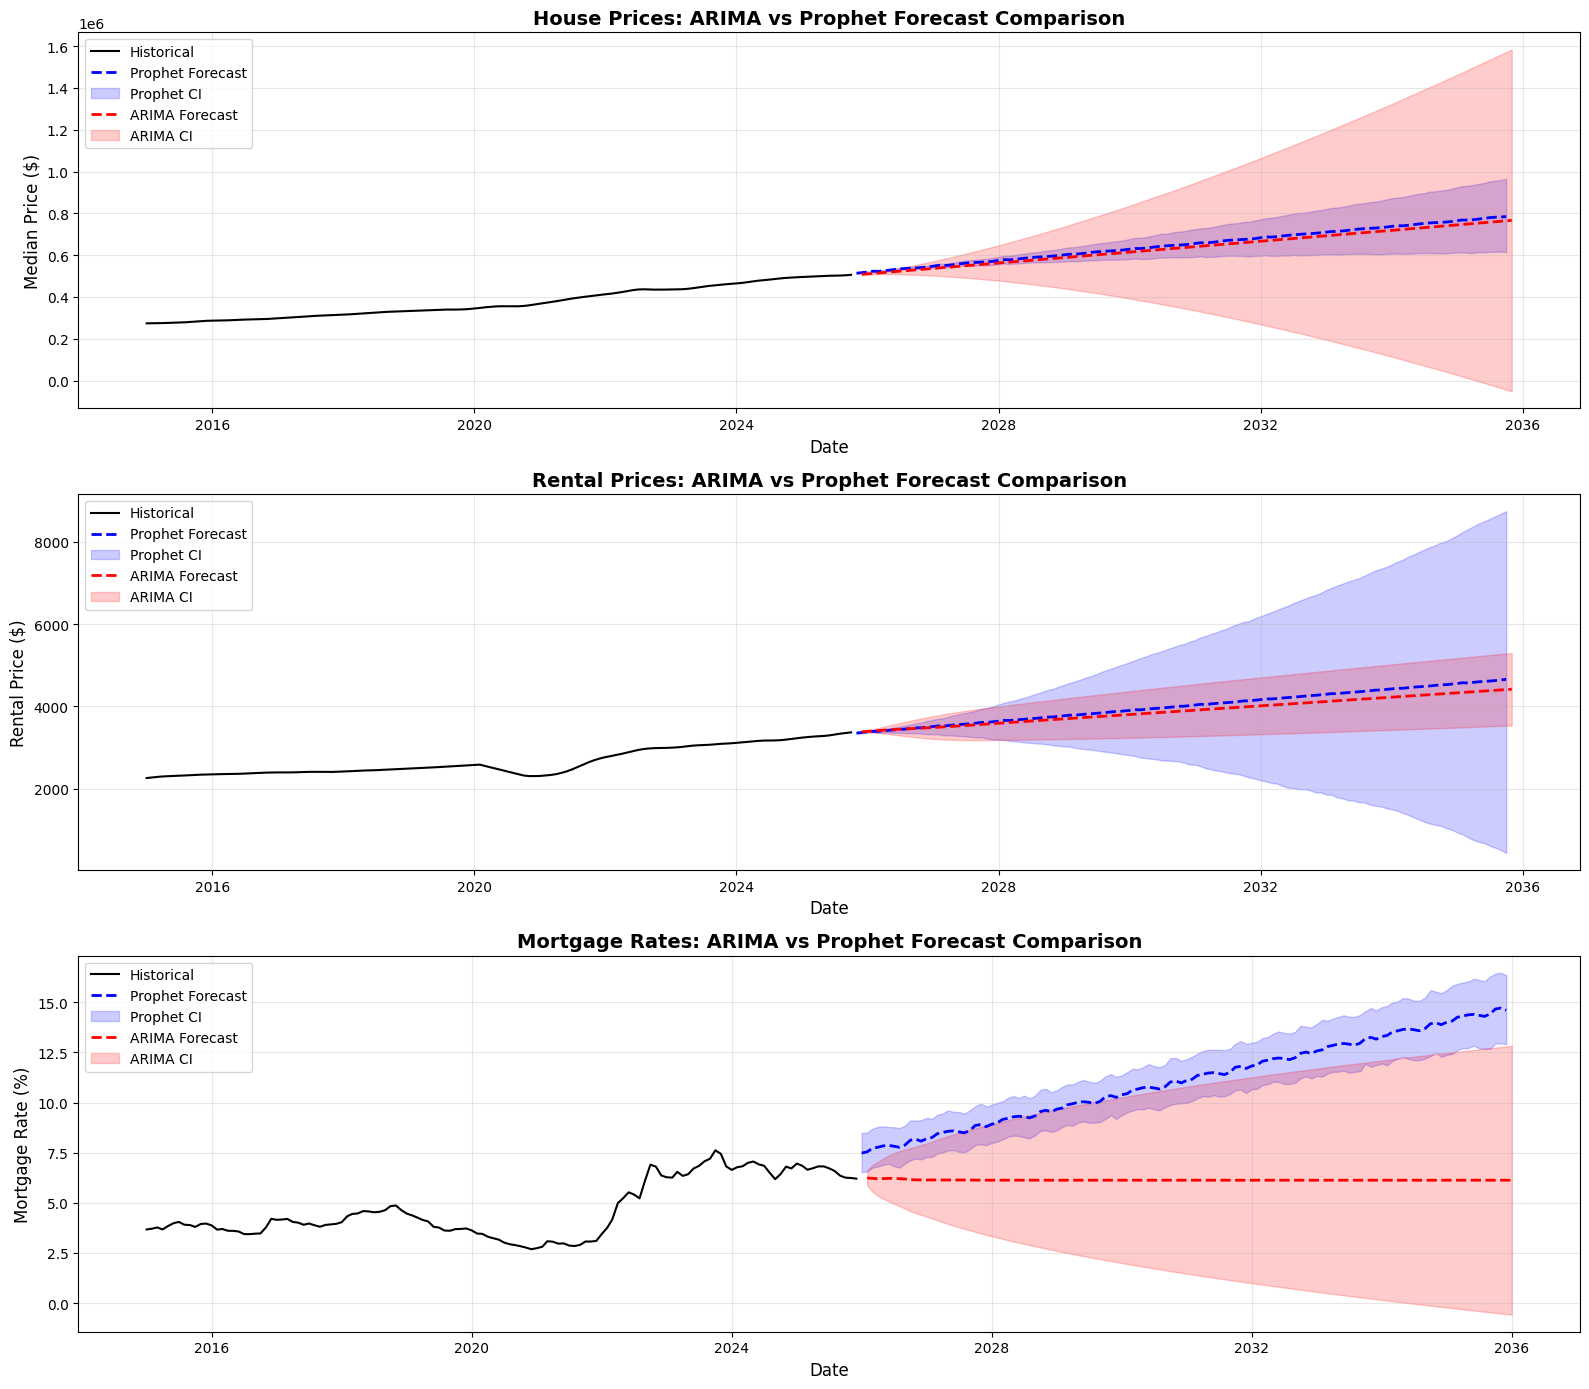

In [135]:
# ============================================
# VISUALIZATION: ARIMA vs PROPHET COMPARISON
# ============================================

# Prepare Prophet forecasts for comparison (extract future forecasts only)
prophet_house_future = forecast_house_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]
prophet_rental_future = forecast_rental_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]
prophet_mortgage_future = forecast_mortgage_future.set_index('ds')[['yhat', 'yhat_lower', 'yhat_upper']]

# Create comparison plots
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ===== HOUSE PRICES =====
ax = axes[0]
# Historical data
ax.plot(house_prices_ts.index, house_prices_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_house_future.index, prophet_house_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_house_future.index, prophet_house_future['yhat_lower'], 
                prophet_house_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_house_df.index, forecast_arima_house_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_house_df.index, forecast_arima_house_df['lower'], 
                forecast_arima_house_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('House Prices: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Median Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ===== RENTAL PRICES =====
ax = axes[1]
# Historical data
ax.plot(rental_prices_ts.index, rental_prices_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_rental_future.index, prophet_rental_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_rental_future.index, prophet_rental_future['yhat_lower'], 
                prophet_rental_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_rental_df.index, forecast_arima_rental_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_rental_df.index, forecast_arima_rental_df['lower'], 
                forecast_arima_rental_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('Rental Prices: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Rental Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

# ===== MORTGAGE RATES =====
ax = axes[2]
# Historical data
ax.plot(mortgage_rates_ts.index, mortgage_rates_ts.values, 'k-', label='Historical', linewidth=1.5)
# Prophet forecast
ax.plot(prophet_mortgage_future.index, prophet_mortgage_future['yhat'], 'b--', label='Prophet Forecast', linewidth=2)
ax.fill_between(prophet_mortgage_future.index, prophet_mortgage_future['yhat_lower'], 
                prophet_mortgage_future['yhat_upper'], alpha=0.2, color='blue', label='Prophet CI')
# ARIMA forecast
ax.plot(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['forecast'], 'r--', label='ARIMA Forecast', linewidth=2)
ax.fill_between(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['lower'], 
                forecast_arima_mortgage_df['upper'], alpha=0.2, color='red', label='ARIMA CI')
ax.set_title('Mortgage Rates: ARIMA vs Prophet Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Mortgage Rate (%)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


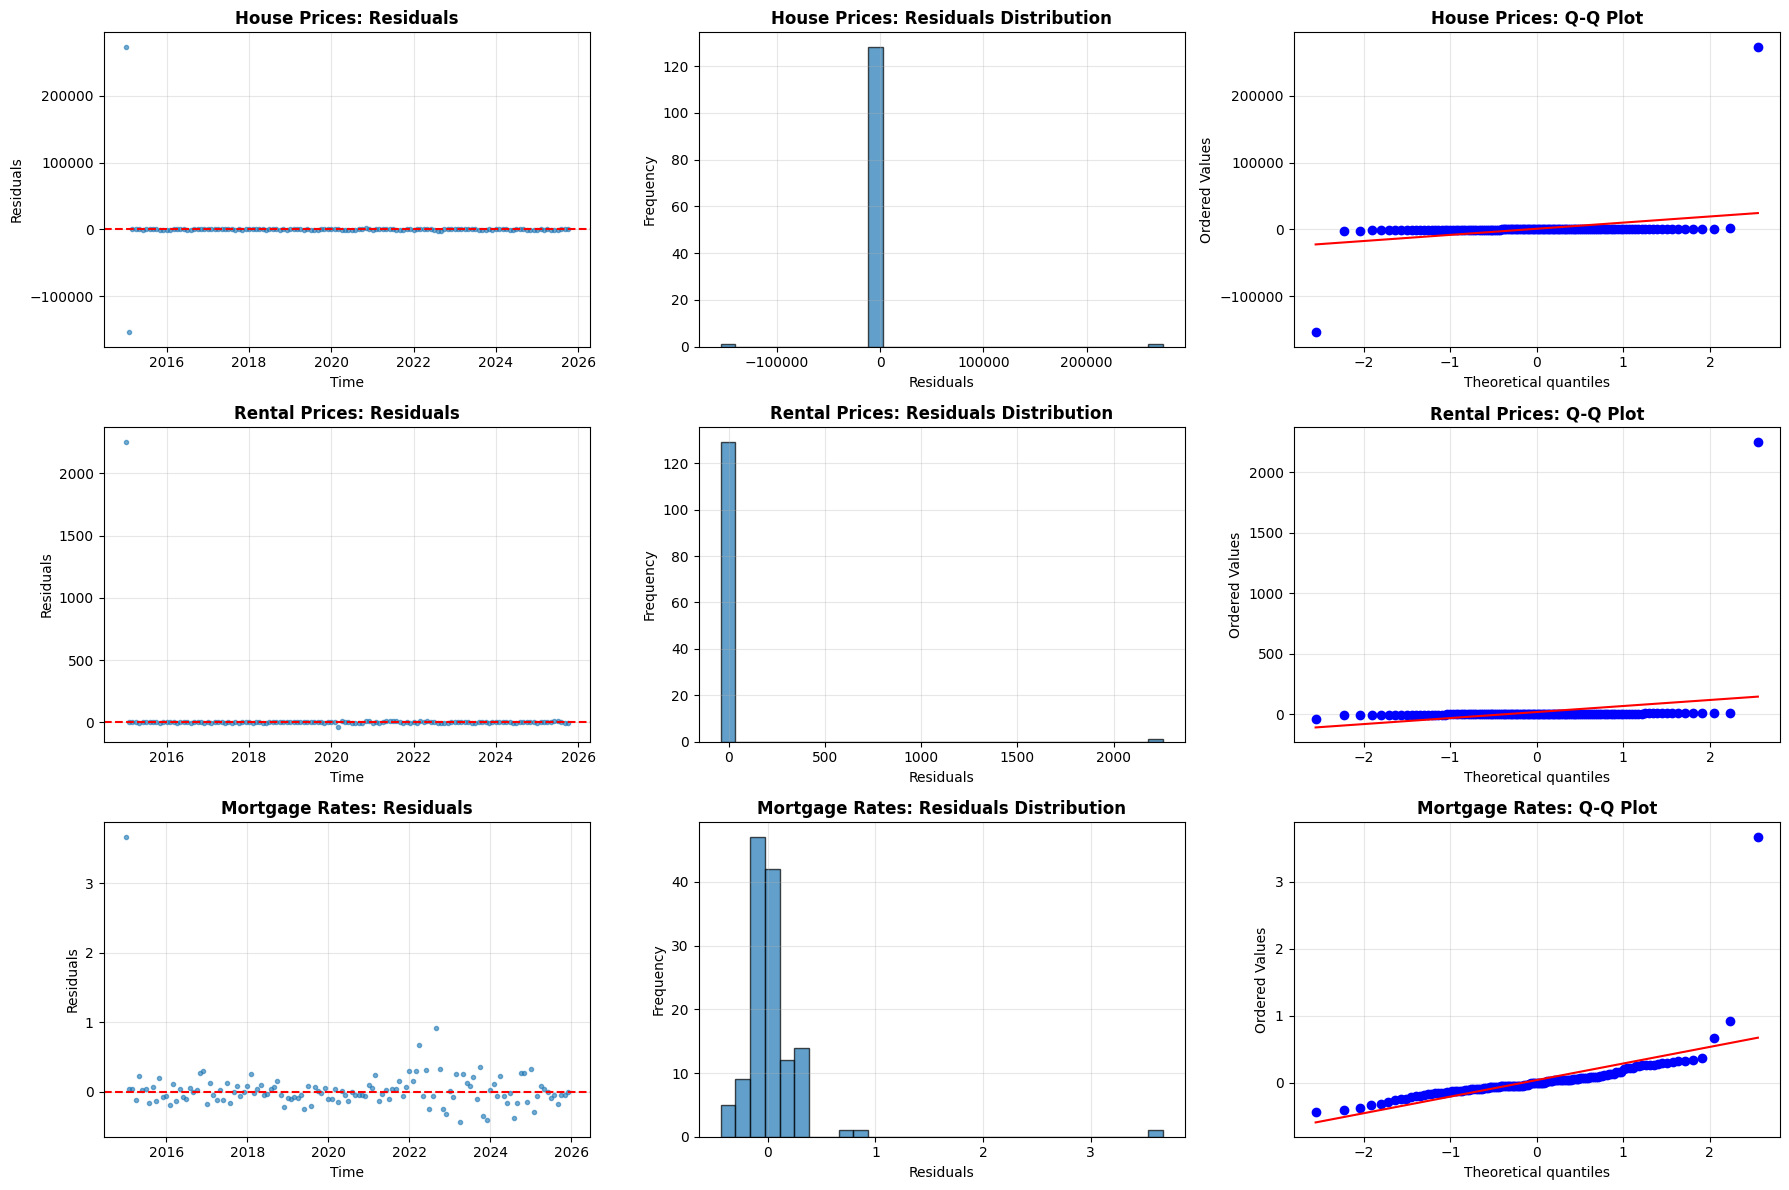

In [136]:
# ============================================
# MODEL DIAGNOSTICS: RESIDUALS ANALYSIS
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# ===== HOUSE PRICES RESIDUALS =====
residuals_house = arima_model_house.resid()

# Residuals plot
axes[0, 0].plot(residuals_house, 'o', markersize=3, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('House Prices: Residuals', fontweight='bold')
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[0, 1].hist(residuals_house, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('House Prices: Residuals Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals_house, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('House Prices: Q-Q Plot', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# ===== RENTAL PRICES RESIDUALS =====
residuals_rental = arima_model_rental.resid()

# Residuals plot
axes[1, 0].plot(residuals_rental, 'o', markersize=3, alpha=0.6)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Rental Prices: Residuals', fontweight='bold')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[1, 1].hist(residuals_rental, bins=30, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Rental Prices: Residuals Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals_rental, dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Rental Prices: Q-Q Plot', fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

# ===== MORTGAGE RATES RESIDUALS =====
residuals_mortgage = arima_model_mortgage.resid()

# Residuals plot
axes[2, 0].plot(residuals_mortgage, 'o', markersize=3, alpha=0.6)
axes[2, 0].axhline(y=0, color='r', linestyle='--')
axes[2, 0].set_title('Mortgage Rates: Residuals', fontweight='bold')
axes[2, 0].set_xlabel('Time')
axes[2, 0].set_ylabel('Residuals')
axes[2, 0].grid(True, alpha=0.3)

# Residuals histogram
axes[2, 1].hist(residuals_mortgage, bins=30, edgecolor='black', alpha=0.7)
axes[2, 1].set_title('Mortgage Rates: Residuals Distribution', fontweight='bold')
axes[2, 1].set_xlabel('Residuals')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals_mortgage, dist="norm", plot=axes[2, 2])
axes[2, 2].set_title('Mortgage Rates: Q-Q Plot', fontweight='bold')
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [137]:
# ============================================
# MODEL COMPARISON: AIC AND STATISTICS
# ============================================

# Create comparison table
comparison_data = {
    'Model': ['House Prices ARIMA', 'House Prices Prophet',
              'Rental Prices ARIMA', 'Rental Prices Prophet',
              'Mortgage Rates ARIMA', 'Mortgage Rates Prophet'],
    'AIC': [
        arima_model_house.aic(),
        None,  # Prophet doesn't use AIC
        arima_model_rental.aic(),
        None,
        arima_model_mortgage.aic(),
        None
    ],
    'Order': [
        f"{auto_model_house.order} x {auto_model_house.seasonal_order}",
        'Prophet',
        f"{auto_model_rental.order} x {auto_model_rental.seasonal_order}",
        'Prophet',
        f"{auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}",
        'Prophet'
    ],
    'Residuals_Mean': [
        residuals_house.mean(),
        None,
        residuals_rental.mean(),
        None,
        residuals_mortgage.mean(),
        None
    ],
    'Residuals_Std': [
        residuals_house.std(),
        None,
        residuals_rental.std(),
        None,
        residuals_mortgage.std(),
        None
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Print ARIMA model details
print("\n" + "=" * 80)
print("ARIMA MODEL DETAILS")
print("=" * 80)
print(f"\nHouse Prices:")
print(f"  Model Order: {auto_model_house.order}")
print(f"  Seasonal Order: {auto_model_house.seasonal_order}")
print(f"  AIC: {arima_model_house.aic():.2f}")
print(f"  Residuals Mean: {residuals_house.mean():.4f}")
print(f"  Residuals Std: {residuals_house.std():.4f}")

print(f"\nRental Prices:")
print(f"  Model Order: {auto_model_rental.order}")
print(f"  Seasonal Order: {auto_model_rental.seasonal_order}")
print(f"  AIC: {arima_model_rental.aic():.2f}")
print(f"  Residuals Mean: {residuals_rental.mean():.4f}")
print(f"  Residuals Std: {residuals_rental.std():.4f}")

print(f"\nMortgage Rates:")
print(f"  Model Order: {auto_model_mortgage.order}")
print(f"  Seasonal Order: {auto_model_mortgage.seasonal_order}")
print(f"  AIC: {arima_model_mortgage.aic():.2f}")
print(f"  Residuals Mean: {residuals_mortgage.mean():.4f}")
print(f"  Residuals Std: {residuals_mortgage.std():.4f}")


MODEL COMPARISON SUMMARY
                 Model         AIC                     Order  Residuals_Mean  Residuals_Std
    House Prices ARIMA 1978.964777 (0, 2, 0) x (0, 0, 0, 12)      933.062604   27668.973210
  House Prices Prophet         NaN                   Prophet             NaN            NaN
   Rental Prices ARIMA  796.643868 (2, 1, 1) x (0, 0, 0, 12)       17.341628     197.871801
 Rental Prices Prophet         NaN                   Prophet             NaN            NaN
  Mortgage Rates ARIMA  -63.298795 (0, 1, 1) x (1, 0, 0, 12)        0.038692       0.368384
Mortgage Rates Prophet         NaN                   Prophet             NaN            NaN

ARIMA MODEL DETAILS

House Prices:
  Model Order: (0, 2, 0)
  Seasonal Order: (0, 0, 0, 12)
  AIC: 1978.96
  Residuals Mean: 933.0626
  Residuals Std: 27668.9732

Rental Prices:
  Model Order: (2, 1, 1)
  Seasonal Order: (0, 0, 0, 12)
  AIC: 796.64
  Residuals Mean: 17.3416
  Residuals Std: 197.8718

Mortgage Rates:
  Model Orde

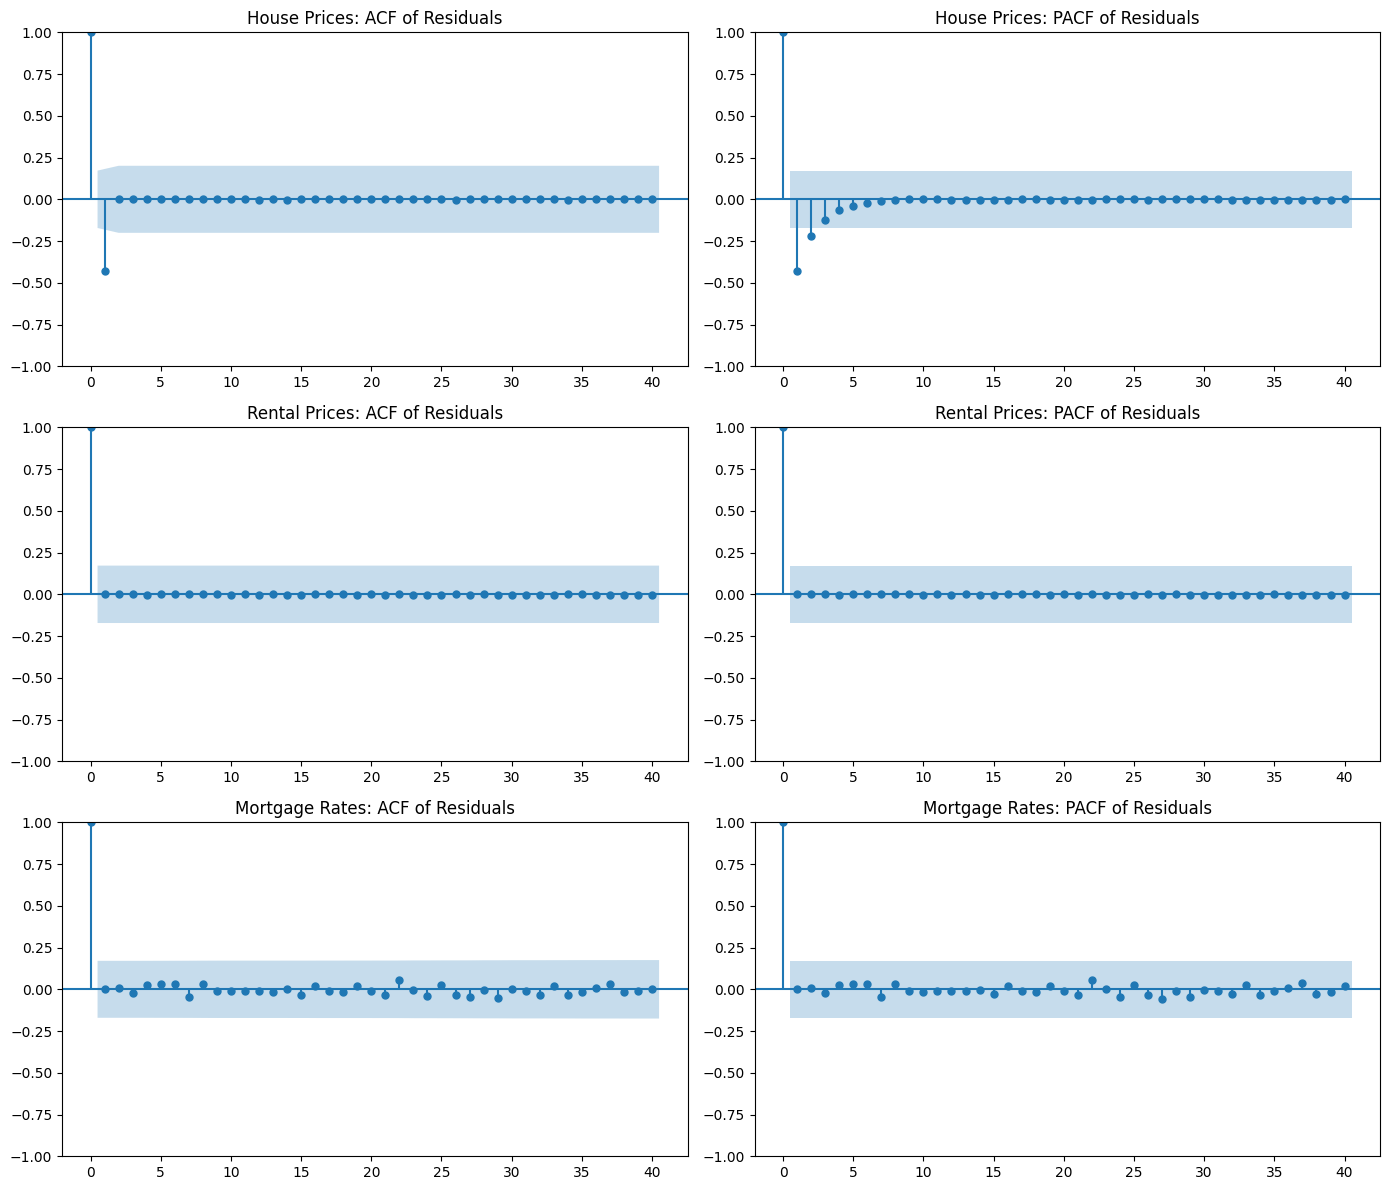

LJUNG-BOX TEST FOR RESIDUAL AUTOCORRELATION

Null Hypothesis: Residuals are independently distributed
(p-value > 0.05 indicates no significant autocorrelation)

House Prices:
  Ljung-Box p-value (lag 10): 0.0070
  ✗ Residuals show autocorrelation

Rental Prices:
  Ljung-Box p-value (lag 10): 1.0000
  ✓ Residuals are independent

Mortgage Rates:
  Ljung-Box p-value (lag 10): 0.9999
  ✓ Residuals are independent


In [138]:
# ============================================
# ACF/PACF PLOTS FOR RESIDUAL DIAGNOSTICS
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# House Prices ACF/PACF
plot_acf(residuals_house, lags=40, ax=axes[0, 0], title='House Prices: ACF of Residuals')
plot_pacf(residuals_house, lags=40, ax=axes[0, 1], title='House Prices: PACF of Residuals')

# Rental Prices ACF/PACF
plot_acf(residuals_rental, lags=40, ax=axes[1, 0], title='Rental Prices: ACF of Residuals')
plot_pacf(residuals_rental, lags=40, ax=axes[1, 1], title='Rental Prices: PACF of Residuals')

# Mortgage Rates ACF/PACF
plot_acf(residuals_mortgage, lags=40, ax=axes[2, 0], title='Mortgage Rates: ACF of Residuals')
plot_pacf(residuals_mortgage, lags=40, ax=axes[2, 1], title='Mortgage Rates: PACF of Residuals')

plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
print("=" * 80)
print("LJUNG-BOX TEST FOR RESIDUAL AUTOCORRELATION")
print("=" * 80)
print("\nNull Hypothesis: Residuals are independently distributed")
print("(p-value > 0.05 indicates no significant autocorrelation)\n")

lb_house = acorr_ljungbox(residuals_house, lags=10, return_df=True)
print("House Prices:")
print(f"  Ljung-Box p-value (lag 10): {lb_house['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_house['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")

lb_rental = acorr_ljungbox(residuals_rental, lags=10, return_df=True)
print("\nRental Prices:")
print(f"  Ljung-Box p-value (lag 10): {lb_rental['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_rental['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")

lb_mortgage = acorr_ljungbox(residuals_mortgage, lags=10, return_df=True)
print("\nMortgage Rates:")
print(f"  Ljung-Box p-value (lag 10): {lb_mortgage['lb_pvalue'].iloc[-1]:.4f}")
print(f"  {'✓ Residuals are independent' if lb_mortgage['lb_pvalue'].iloc[-1] > 0.05 else '✗ Residuals show autocorrelation'}")


In [139]:
# ============================================
# FORECAST SUMMARY: ARIMA vs PROPHET
# ============================================

# Create a summary comparison of forecast values
print("=" * 80)
print("FORECAST SUMMARY COMPARISON (10 Years Ahead)")
print("=" * 80)

# House Prices
print("\nHOUSE PRICES:")
print(f"  Historical Last Value: ${house_prices_ts.iloc[-1]:,.2f}")
print(f"  ARIMA Forecast (10 years): ${forecast_arima_house_df['forecast'].iloc[-1]:,.2f}")
print(f"    Change: {((forecast_arima_house_df['forecast'].iloc[-1] / house_prices_ts.iloc[-1]) - 1) * 100:.2f}%")
print(f"  Prophet Forecast (10 years): ${prophet_house_future['yhat'].iloc[-1]:,.2f}")
print(f"    Change: {((prophet_house_future['yhat'].iloc[-1] / house_prices_ts.iloc[-1]) - 1) * 100:.2f}%")

# Rental Prices
print("\nRENTAL PRICES:")
print(f"  Historical Last Value: ${rental_prices_ts.iloc[-1]:,.2f}")
print(f"  ARIMA Forecast (10 years): ${forecast_arima_rental_df['forecast'].iloc[-1]:,.2f}")
print(f"    Change: {((forecast_arima_rental_df['forecast'].iloc[-1] / rental_prices_ts.iloc[-1]) - 1) * 100:.2f}%")
print(f"  Prophet Forecast (10 years): ${prophet_rental_future['yhat'].iloc[-1]:,.2f}")
print(f"    Change: {((prophet_rental_future['yhat'].iloc[-1] / rental_prices_ts.iloc[-1]) - 1) * 100:.2f}%")

# Mortgage Rates
print("\nMORTGAGE RATES:")
print(f"  Historical Last Value: {mortgage_rates_ts.iloc[-1]:.2f}%")
print(f"  ARIMA Forecast (10 years): {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%")
print(f"    Change: {forecast_arima_mortgage_df['forecast'].iloc[-1] - mortgage_rates_ts.iloc[-1]:.2f} percentage points")
print(f"  Prophet Forecast (10 years): {prophet_mortgage_future['yhat'].iloc[-1]:.2f}%")
print(f"    Change: {prophet_mortgage_future['yhat'].iloc[-1] - mortgage_rates_ts.iloc[-1]:.2f} percentage points")

print("\n" + "=" * 80)
print("ARIMA/SARIMA FORECASTING COMPLETE")
print("=" * 80)


FORECAST SUMMARY COMPARISON (10 Years Ahead)

HOUSE PRICES:
  Historical Last Value: $505,959.52
  ARIMA Forecast (10 years): $766,543.27
    Change: 51.50%
  Prophet Forecast (10 years): $784,195.61
    Change: 54.99%

RENTAL PRICES:
  Historical Last Value: $3,372.41
  ARIMA Forecast (10 years): $4,419.22
    Change: 31.04%
  Prophet Forecast (10 years): $4,659.61
    Change: 38.17%

MORTGAGE RATES:
  Historical Last Value: 6.21%
  ARIMA Forecast (10 years): 6.13%
    Change: -0.08 percentage points
  Prophet Forecast (10 years): 14.61%
    Change: 8.40 percentage points

ARIMA/SARIMA FORECASTING COMPLETE
